In [1]:
import sys
print(sys.version)

3.13.12 (main, Feb  3 2026, 22:52:12) [Clang 21.1.4 ]


# Fast Agent - Build a SQL Agent fast!

<img src="./assets/LC_L1_Top.png" align="left" width="500">

## Setup

Load and/or check for needed environmental variables

In [2]:
import os
from dotenv import load_dotenv
from env_utils import doublecheck_env, doublecheck_pkgs

# Load environment variables from .env
load_dotenv()

# Check and print results
doublecheck_env("example.env")  # check environmental variables
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)   # check packages

AI_API_KEY=****1zgM
AI_MODEL=google_genai:gemini-2.5-flash
LANGSMITH_API_KEY=****0a4f
LANGSMITH_TRACING=false
LANGSMITH_PROJECT=My Test Project
Python 3.13.12 satisfies requires-python: >=3.11,<3.14
package                | required | installed | status | path                                                                            
---------------------- | -------- | --------- | ------ | --------------------------------------------------------------------------------
langgraph              | >=1.0.0  | 1.2.9     | ✅ OK   | …repo/github/lca-langchainV1-essentials/python/venv/lib/python3.13/site-packages
langchain              | >=1.3.10 | 1.3.14    | ✅ OK   | …repo/github/lca-langchainV1-essentials/python/venv/lib/python3.13/site-packages
langchain-core         | >=1.4.0  | 1.6.3     | ✅ OK   | …repo/github/lca-langchainV1-essentials/python/venv/lib/python3.13/site-packages
langchain-google-genai | >=2.0.0  | 4.4.0     | ✅ OK   | …repo/github/lca-langchainV1-essentials/python/venv/li

In [3]:
from sql_db import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

Define the runtime context to provide the agent and tools with access to the database.

In [4]:
from dataclasses import dataclass

from sql_db import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

<b>⚠️ Security Note:</b> This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️   
This tool will connect to the database. Note the use of `get_runtime` to access the graph **runtime context**.

In [5]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [6]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go!  You can choose many agents from our [integrations](https://docs.langchain.com/oss/python/integrations/providers) list. 

In [7]:
from langchain.agents import create_agent

agent = create_agent(
    model=os.getenv("AI_MODEL", "google_genai:gemini-2.5-flash"),
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.

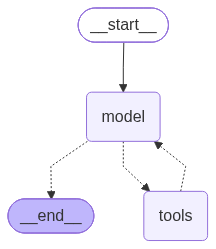

In [8]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:
- The agent does not have the database schema and will need to discover it independently.
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
- Notice you invoke the agent with `agent.stream`.
    - This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
- Notice the agent doesn't remember the schema between invocations... More on this later!

In [9]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?


GoogleModelNotFoundError: Error calling model 'gemini-2.5-flash' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use models/gemini-3.6-flash for the latest features and improvements. We recommend you to use the Interactions API.', 'status': 'NOT_FOUND'}}

In [ ]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

In [ ]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

**Create your own query here!**  Add some questions of your own.

In [ ]:
question = "Дай мне список всех таблиц в строке, которая является asciidoc-файлом с заголовком и таблицей с колонками: имя таблицы, описание таблицы, количество строк, главный индекс. Отсортируй таблицу по количеству строк по убыванию."

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

### Let's try this in Studio